# Chặng 0 — Hiểu Target Variable: `sales.csv`

**Mục tiêu:** Nhìn thấy nghịch lý cốt lõi mà BA team phát hiện:
> Revenue giảm từ 2019, nhưng AOV (giá trị đơn trung bình) lại tăng đều

**Câu hỏi cần trả lời trong notebook này:**
1. Revenue và Gross Margin trông như thế nào theo thời gian?
2. Seasonality có nhất quán không? Peak ở tháng nào?
3. AOV theo thời gian — tăng hay giảm?
4. Volume đơn hàng — tăng hay giảm?
5. Nghịch lý AOV tăng / Volume giảm xuất hiện từ năm nào?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.0f}'.format)

INPUT_DIR = Path('input')

# Palette nhất quán
C_REVENUE  = '#1D9E75'   # xanh teal
C_COGS     = '#E24B4A'   # đỏ
C_PROFIT   = '#378ADD'   # xanh blue
C_VOLUME   = '#888780'   # xám
C_AOV      = '#EF9F27'   # cam
C_PROMO    = '#D4537E'   # hồng

def fmt_vnd(x, pos=None):
    """Format số lớn: 1M, 5B..."""
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    return f'{x:,.0f}'

print('✅ Setup OK')

✅ Setup OK


## 1. Load data

In [2]:
# --- Sales (target) ---
sales = pd.read_csv(INPUT_DIR / 'sales.csv', parse_dates=['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)
sales['GrossProfit'] = sales['Revenue'] - sales['COGS']
sales['GrossMargin%'] = sales['GrossProfit'] / sales['Revenue'] * 100
sales['Year']  = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['YearMonth'] = sales['Date'].dt.to_period('M')

# --- Orders (để tính Volume và AOV) ---
orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
orders['Year']  = orders['order_date'].dt.year
orders['Month'] = orders['order_date'].dt.month
orders['YearMonth'] = orders['order_date'].dt.to_period('M')

# --- Payments (để tính AOV thực tế) ---
payments = pd.read_csv(INPUT_DIR / 'payments.csv')

# --- Promotions ---
promos = pd.read_csv(INPUT_DIR / 'promotions.csv', parse_dates=['start_date','end_date'])

print(f'Sales: {len(sales):,} rows | {sales["Date"].min().date()} → {sales["Date"].max().date()}')
print(f'Orders: {len(orders):,} rows')
print(f'Payments: {len(payments):,} rows')
print(f'Promotions: {len(promos):,} campaigns')
print()
sales[['Date','Revenue','COGS','GrossProfit','GrossMargin%']].head()

Sales: 3,833 rows | 2012-07-04 → 2022-12-31
Orders: 646,945 rows
Payments: 646,945 rows
Promotions: 50 campaigns



,Date,Revenue,COGS,GrossProfit,GrossMargin%
0,2012-07-04,"5,123,548","3,982,991","1,140,557",22
1,2012-07-05,"2,751,773","2,150,580","601,193",22
2,2012-07-06,"3,054,029","2,517,633","536,397",18
3,2012-07-07,"2,667,931","2,108,247","559,684",21
4,2012-07-08,"2,360,852","1,808,623","552,229",23


## 2. Tính AOV và Volume theo tháng

**AOV = Average Order Value = tổng doanh thu / số đơn hàng**  
Đây là metric quan trọng nhất để giải thích nghịch lý BA team phát hiện.

In [3]:
# Revenue + COGS theo tháng từ sales.csv
monthly_sales = sales.groupby('YearMonth').agg(
    Revenue     = ('Revenue', 'sum'),
    COGS        = ('COGS', 'sum'),
    GrossProfit = ('GrossProfit', 'sum'),
).reset_index()
monthly_sales['GrossMargin%'] = monthly_sales['GrossProfit'] / monthly_sales['Revenue'] * 100
monthly_sales['Year']  = monthly_sales['YearMonth'].dt.year
monthly_sales['Month'] = monthly_sales['YearMonth'].dt.month

# Volume đơn hàng theo tháng (chỉ delivered để công bằng)
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
monthly_volume = orders_delivered.groupby('YearMonth').agg(
    n_orders = ('order_id', 'count')
).reset_index()

# AOV = Revenue / n_orders theo tháng
monthly = monthly_sales.merge(
    monthly_volume, on='YearMonth', how='left'
)
monthly['AOV'] = monthly['Revenue'] / monthly['n_orders']
monthly['Date'] = monthly['YearMonth'].dt.to_timestamp()

# Yearly summary
yearly = monthly.groupby('Year').agg(
    Revenue     = ('Revenue', 'sum'),
    COGS        = ('COGS', 'sum'),
    GrossProfit = ('GrossProfit', 'sum'),
    n_orders    = ('n_orders', 'sum'),
).reset_index()
yearly['GrossMargin%'] = yearly['GrossProfit'] / yearly['Revenue'] * 100
yearly['AOV'] = yearly['Revenue'] / yearly['n_orders']

print('Yearly summary:')
print(yearly[['Year','Revenue','GrossProfit','GrossMargin%','n_orders','AOV']].to_string(index=False))

Yearly summary:
 Year       Revenue  GrossProfit  GrossMargin%  n_orders    AOV
 2012   741,497,748  154,035,824            21     25663 28,894
 2013 1,657,169,417  191,189,314            12     61588 26,907
 2014 1,871,845,883  297,238,426            16     64688 28,937
 2015 1,889,933,827  224,492,010            12     66163 28,565
 2016 2,104,640,678  324,081,285            15     66067 31,856
 2017 1,911,164,325  216,778,532            11     61144 31,257
 2018 1,850,122,456  307,946,690            17     55740 33,192
 2019 1,136,801,442  131,598,558            12     33259 34,180
 2020 1,054,512,159  168,427,061            16     27975 37,695
 2021 1,043,039,820  101,909,699            10     26741 39,005
 2022 1,169,748,832  149,328,668            13     27688 42,248


## 3. Big Picture — Revenue, Gross Profit và Margin theo năm

comment: Khách hàng chi nhiều tiền hơn cho mỗi đơn (AOV tăng), nhưng nền tảng lại giữ lại được ít tiền lời hơn (Margin tụt).

Tại sao lại có chuyện này?
Chắc chắn họ không tăng AOV bằng cách up-sell thành công các sản phẩm cao cấp (premium). Thay vào đó, họ ép AOV tăng bằng các combo giảm giá hủy diệt (Ví dụ: "Mua 3 áo giảm ngay 50%"). Khách hàng nhặt thêm đồ vào giỏ để lấy khuyến mãi, khiến bill to lên, nhưng giá bán thực tế cho mỗi món đồ bị ép xuống quá gần với Giá vốn hàng bán (COGS). Hệ quả là đơn hàng trông rất to, nhưng tiền lời chỉ là bạc cắc.

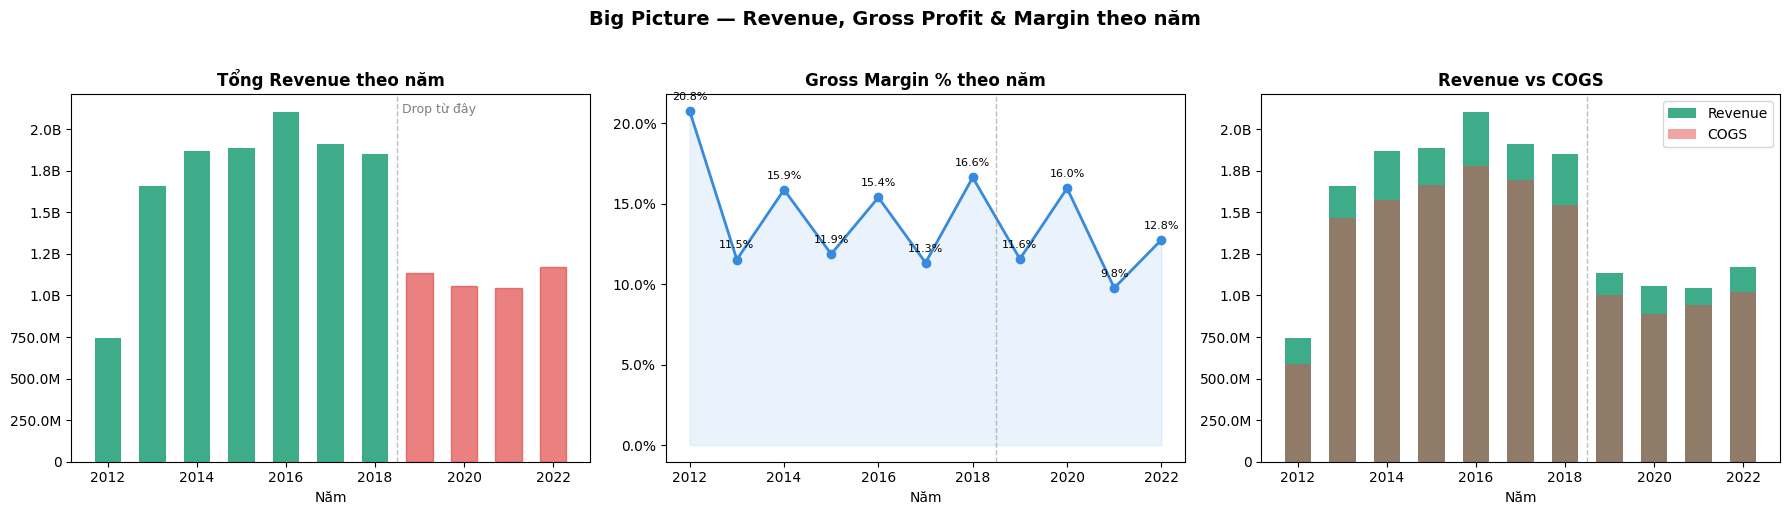


💡 Quan sát: Revenue và Gross Profit đạt peak ở đâu? Margin có ổn định không?


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Big Picture — Revenue, Gross Profit & Margin theo năm', 
             fontsize=14, fontweight='bold', y=1.02)

# Revenue theo năm
ax = axes[0]
bars = ax.bar(yearly['Year'], yearly['Revenue'], color=C_REVENUE, alpha=0.85, width=0.6)
ax.set_title('Tổng Revenue theo năm', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_vnd))
ax.set_xlabel('Năm')
# Highlight drop từ 2019
peak_year = yearly.loc[yearly['Revenue'].idxmax(), 'Year']
for bar, year in zip(bars, yearly['Year']):
    if year >= 2019:
        bar.set_color(C_COGS)
        bar.set_alpha(0.7)
ax.axvline(x=2018.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(2018.6, ax.get_ylim()[1]*0.95, 'Drop từ đây', fontsize=9, color='gray')

# Gross Margin % theo năm
ax = axes[1]
ax.plot(yearly['Year'], yearly['GrossMargin%'], 
        color=C_PROFIT, marker='o', linewidth=2, markersize=6)
ax.fill_between(yearly['Year'], yearly['GrossMargin%'], alpha=0.1, color=C_PROFIT)
ax.set_title('Gross Margin % theo năm', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_xlabel('Năm')
ax.axvline(x=2018.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
for x, y in zip(yearly['Year'], yearly['GrossMargin%']):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', 
                xytext=(0, 8), ha='center', fontsize=8)

# Revenue vs COGS stacked
ax = axes[2]
ax.bar(yearly['Year'], yearly['Revenue'], label='Revenue', color=C_REVENUE, alpha=0.85, width=0.6)
ax.bar(yearly['Year'], yearly['COGS'], label='COGS', color=C_COGS, alpha=0.5, width=0.6)
ax.set_title('Revenue vs COGS', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_vnd))
ax.set_xlabel('Năm')
ax.legend()
ax.axvline(x=2018.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('c0_01_big_picture.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Quan sát: Revenue và Gross Profit đạt peak ở đâu? Margin có ổn định không?')

## 4. Nghịch lý cốt lõi: AOV tăng nhưng Volume giảm

Với công thức Doanh thu (Revenue) = Số đơn hàng (Volume) x Giá trị đơn trung bình (AOV)
Năm đỉnh cao (2016): 66,067 đơn x 31,856 = ~2.1 tỷ

Năm 2022: 27,688 đơn x 42,248 = ~1.16 tỷ

Dù AOV đã tăng gần 35% từ đỉnh, nhưng Volume lại bốc hơi hơn 50%. Kết quả là tổng doanh thu đã chia đôi. Sự tăng trưởng của AOV không đủ sức bù đắp cho sự sụt giảm tàn khốc của lượng đơn hàng.

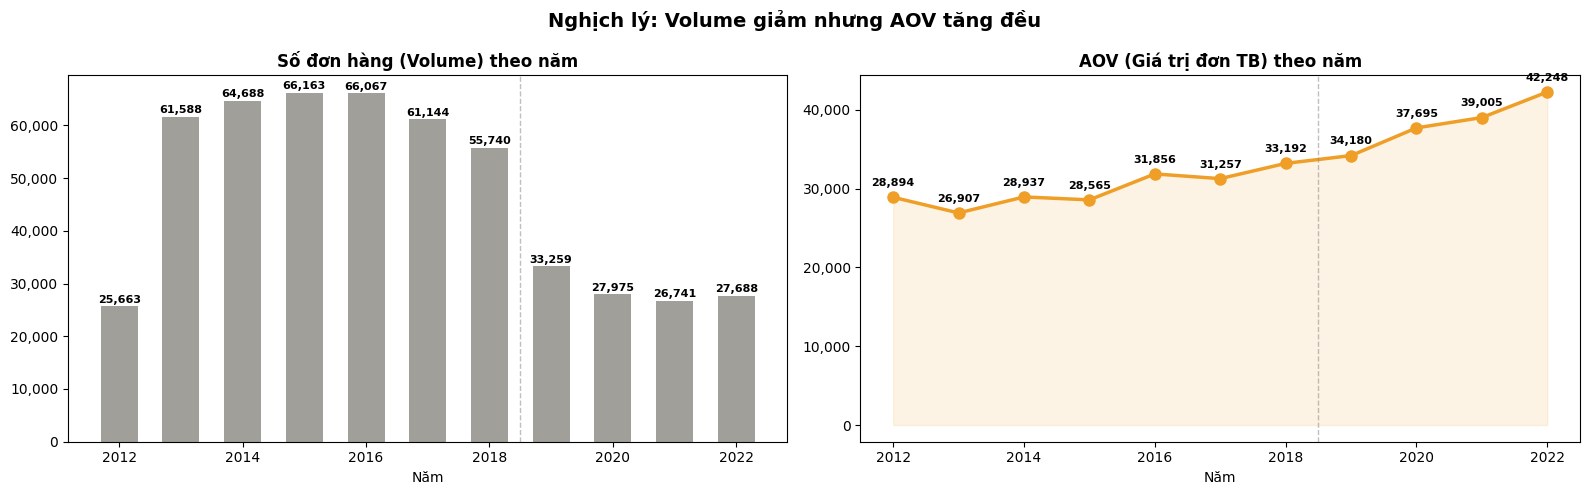


📊 Nghịch lý:
   Volume: 66,163 đơn (2015) → 27,688 đơn (2022)
           Giảm 58.2%
   AOV:    28,565 (2015) → 42,248 (2022)
           Tăng 47.9%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Nghịch lý: Volume giảm nhưng AOV tăng đều', 
             fontsize=14, fontweight='bold')

# Volume đơn hàng
ax = axes[0]
ax.bar(yearly['Year'], yearly['n_orders'], color=C_VOLUME, alpha=0.8, width=0.6)
ax.set_title('Số đơn hàng (Volume) theo năm', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Năm')
for x, y in zip(yearly['Year'], yearly['n_orders']):
    ax.text(x, y + yearly['n_orders'].max()*0.01, f'{int(y):,}', 
            ha='center', fontsize=8, fontweight='bold')
ax.axvline(x=2018.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# AOV theo năm
ax = axes[1]
ax.plot(yearly['Year'], yearly['AOV'], 
        color=C_AOV, marker='o', linewidth=2.5, markersize=8)
ax.fill_between(yearly['Year'], yearly['AOV'], alpha=0.12, color=C_AOV)
ax.set_title('AOV (Giá trị đơn TB) theo năm', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Năm')
for x, y in zip(yearly['Year'], yearly['AOV']):
    ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, fontweight='bold')
ax.axvline(x=2018.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('c0_02_paradox_volume_aov.png', dpi=150, bbox_inches='tight')
plt.show()

# Tóm tắt số liệu
peak_vol_year = yearly.loc[yearly['n_orders'].idxmax(), 'Year']
latest_year   = yearly['Year'].max()
peak_vol      = yearly.loc[yearly['n_orders'].idxmax(), 'n_orders']
latest_vol    = yearly.loc[yearly['Year'] == latest_year, 'n_orders'].values[0]
peak_aov      = yearly.loc[yearly['Year'] == peak_vol_year, 'AOV'].values[0]
latest_aov    = yearly.loc[yearly['Year'] == latest_year, 'AOV'].values[0]

print(f'\n📊 Nghịch lý:')
print(f'   Volume: {peak_vol:,.0f} đơn ({peak_vol_year}) → {latest_vol:,.0f} đơn ({latest_year})')
print(f'           Giảm {(1 - latest_vol/peak_vol)*100:.1f}%')
print(f'   AOV:    {peak_aov:,.0f} ({peak_vol_year}) → {latest_aov:,.0f} ({latest_year})')
print(f'           Tăng {(latest_aov/peak_aov - 1)*100:.1f}%')

## 5. Seasonality — Peak tháng nào, nhất quán không?

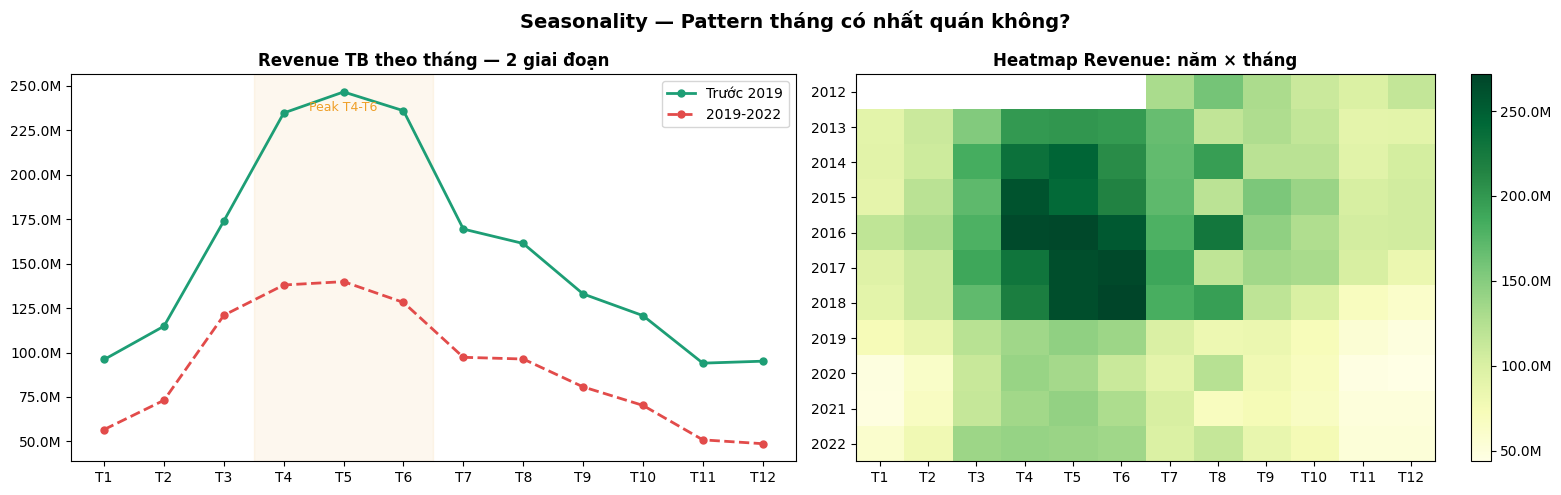

Peak month theo từng năm:
 Year Peak Month Label
 2012               T8
 2013               T5
 2014               T5
 2015               T4
 2016               T5
 2017               T6
 2018               T6
 2019               T5
 2020               T4
 2021               T5
 2022               T4


In [6]:
# Revenue trung bình theo tháng, chia theo giai đoạn trước/sau 2019
monthly['Period'] = monthly['Year'].apply(lambda y: 'Trước 2019' if y < 2019 else '2019-2022')

season_by_period = monthly.groupby(['Period','Month'])['Revenue'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Seasonality — Pattern tháng có nhất quán không?', 
             fontsize=14, fontweight='bold')

month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

# Revenue trung bình theo tháng - 2 giai đoạn
ax = axes[0]
for period, color, ls in [
    ('Trước 2019', C_REVENUE, '-'),
    ('2019-2022',  C_COGS,    '--')
]:
    d = season_by_period[season_by_period['Period'] == period]
    ax.plot(d['Month'], d['Revenue'], 
            label=period, color=color, linewidth=2, 
            linestyle=ls, marker='o', markersize=5)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_title('Revenue TB theo tháng — 2 giai đoạn', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_vnd))
ax.legend()
ax.axvspan(3.5, 6.5, alpha=0.08, color=C_AOV, label='Peak T4-T6')
ax.text(5, ax.get_ylim()[1]*0.92, 'Peak T4-T6', ha='center', fontsize=9, color=C_AOV)

# Heatmap Revenue theo Year x Month
ax = axes[1]
pivot = monthly.pivot_table(values='Revenue', index='Year', columns='Month', aggfunc='sum')
pivot.columns = month_labels
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGn')
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Heatmap Revenue: năm × tháng', fontweight='bold')
plt.colorbar(im, ax=ax, format=mticker.FuncFormatter(fmt_vnd))

plt.tight_layout()
plt.savefig('c0_03_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

# Peak tháng theo năm
peak_months = monthly.groupby('Year').apply(
    lambda g: g.loc[g['Revenue'].idxmax(), 'Month']
).reset_index()
peak_months.columns = ['Year','Peak Month']
peak_months['Peak Month Label'] = peak_months['Peak Month'].apply(lambda m: month_labels[m-1])
print('Peak month theo từng năm:')
print(peak_months[['Year','Peak Month Label']].to_string(index=False))

## 6. AOV theo tháng — tháng có Promotion thì AOV biến đổi thế nào?

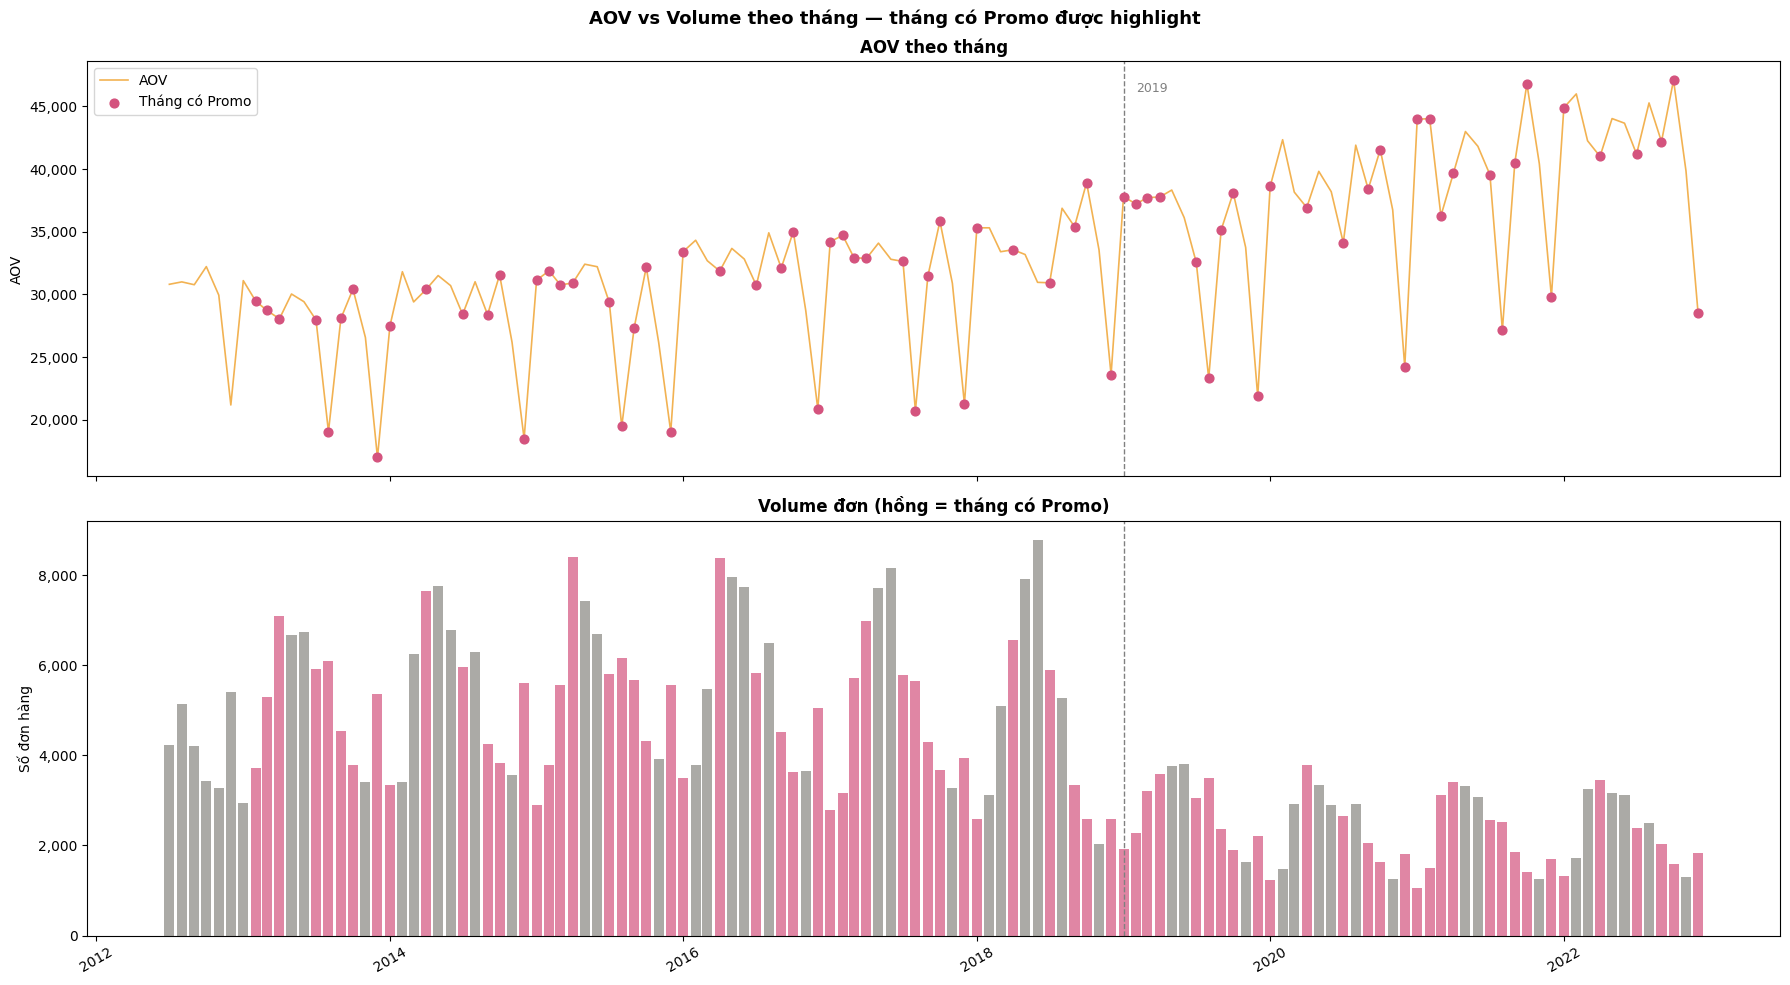


📊 AOV trung bình:
   Tháng CÓ Promo  : 32,323
   Tháng KHÔNG Promo: 34,504

📊 Volume trung bình:
   Tháng CÓ Promo  : 3,865 đơn
   Tháng KHÔNG Promo: 4,436 đơn


In [7]:
# Đánh dấu tháng có promotion
promo_months = set()
for _, row in promos.iterrows():
    months = pd.date_range(row['start_date'], row['end_date'], freq='MS')
    for m in months:
        promo_months.add((m.year, m.month))

monthly['has_promo'] = monthly.apply(
    lambda r: (r['Year'], r['Month']) in promo_months, axis=1
)

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle('AOV vs Volume theo tháng — tháng có Promo được highlight',
             fontsize=13, fontweight='bold')

# AOV theo tháng
ax = axes[0]
ax.plot(monthly['Date'], monthly['AOV'], 
        color=C_AOV, linewidth=1.2, alpha=0.8, label='AOV')
promo_mask = monthly['has_promo']
ax.scatter(monthly.loc[promo_mask, 'Date'],
           monthly.loc[promo_mask, 'AOV'],
           color=C_PROMO, s=40, zorder=5, label='Tháng có Promo')
ax.set_ylabel('AOV')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.set_title('AOV theo tháng', fontweight='bold')
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', linewidth=1)
ax.text(pd.Timestamp('2019-02-01'), ax.get_ylim()[1]*0.95, '2019', fontsize=9, color='gray')

# Volume theo tháng
ax = axes[1]
ax.bar(monthly['Date'], monthly['n_orders'],
       color=[C_PROMO if p else C_VOLUME for p in monthly['has_promo']],
       alpha=0.7, width=25, label='Volume')
ax.set_ylabel('Số đơn hàng')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Volume đơn (hồng = tháng có Promo)', fontweight='bold')
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', linewidth=1)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('c0_04_aov_volume_promo.png', dpi=150, bbox_inches='tight')
plt.show()

# So sánh AOV tháng có promo vs không
print('\n📊 AOV trung bình:')
print(f'   Tháng CÓ Promo  : {monthly.loc[monthly["has_promo"],"AOV"].mean():,.0f}')
print(f'   Tháng KHÔNG Promo: {monthly.loc[~monthly["has_promo"],"AOV"].mean():,.0f}')
print(f'\n📊 Volume trung bình:')
print(f'   Tháng CÓ Promo  : {monthly.loc[monthly["has_promo"],"n_orders"].mean():,.0f} đơn')
print(f'   Tháng KHÔNG Promo: {monthly.loc[~monthly["has_promo"],"n_orders"].mean():,.0f} đơn')

## 7. Revenue hàng ngày — nhìn thấy spike và outlier

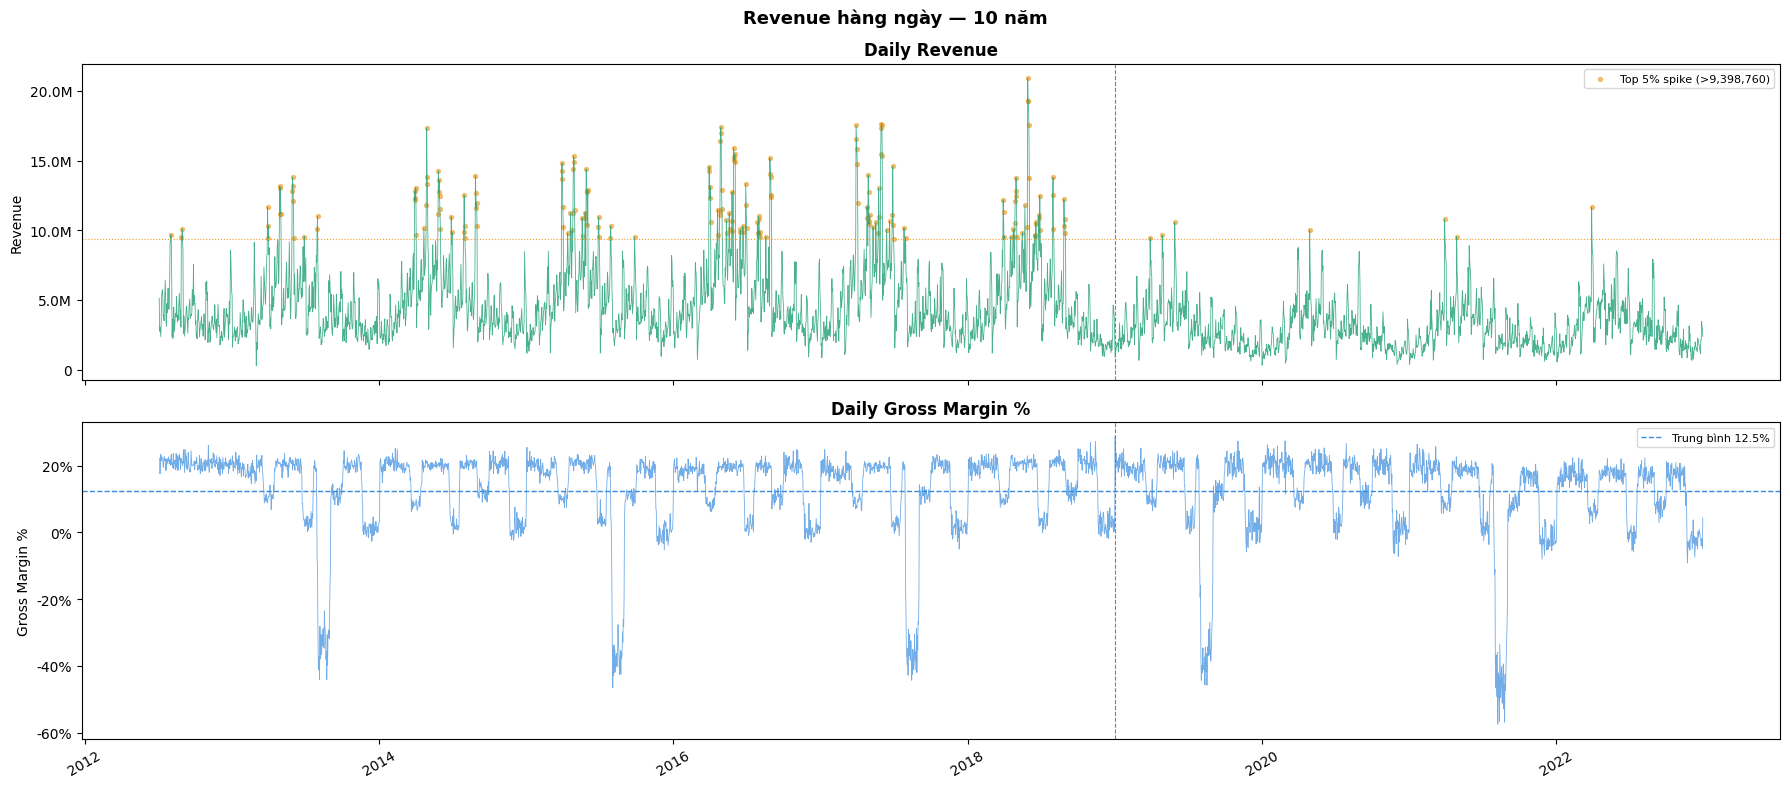


Revenue daily — thống kê:
         Revenue  GrossProfit  GrossMargin%
count      3,833        3,833         3,833
mean   4,286,584      591,450            13
std    2,624,840      666,196            13
min      279,814   -2,567,312           -57
25%    2,471,089      229,274             8
50%    3,647,304      544,554            18
75%    5,350,877      876,081            20
max   20,905,271    4,369,414            29


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
fig.suptitle('Revenue hàng ngày — 10 năm', fontsize=13, fontweight='bold')

# Revenue daily
ax = axes[0]
ax.plot(sales['Date'], sales['Revenue'], 
        color=C_REVENUE, linewidth=0.6, alpha=0.8)

# Highlight top 5% spike
threshold = sales['Revenue'].quantile(0.95)
spikes = sales[sales['Revenue'] > threshold]
ax.scatter(spikes['Date'], spikes['Revenue'], 
           color=C_AOV, s=8, alpha=0.6, label=f'Top 5% spike (>{threshold:,.0f})')
ax.axhline(y=threshold, color=C_AOV, linestyle=':', linewidth=0.8)
ax.set_ylabel('Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_vnd))
ax.legend(fontsize=8)
ax.set_title('Daily Revenue', fontweight='bold')
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', linewidth=0.8)

# Gross Margin% daily
ax = axes[1]
ax.plot(sales['Date'], sales['GrossMargin%'],
        color=C_PROFIT, linewidth=0.6, alpha=0.7)
ax.axhline(y=sales['GrossMargin%'].mean(), color=C_PROFIT, 
           linestyle='--', linewidth=1, 
           label=f'Trung bình {sales["GrossMargin%"].mean():.1f}%')
ax.set_ylabel('Gross Margin %')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=8)
ax.set_title('Daily Gross Margin %', fontweight='bold')
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', linewidth=0.8)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('c0_05_daily_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# Describe
print('\nRevenue daily — thống kê:')
print(sales[['Revenue','GrossProfit','GrossMargin%']].describe().round(0).to_string())

## 8. Tổng kết — 5 phát hiện chính

In [9]:
print('='*65)
print('📋  CHẶNG 0 — TỔNG KẾT PHÁT HIỆN')
print('='*65)

# Tính các số
rev_peak = yearly.loc[yearly['Revenue'].idxmax()]
rev_last = yearly.iloc[-1]
rev_drop = (1 - rev_last['Revenue'] / rev_peak['Revenue']) * 100

aov_first = yearly.iloc[0]['AOV']
aov_last  = yearly.iloc[-1]['AOV']
aov_grow  = (aov_last / aov_first - 1) * 100

vol_first = yearly.iloc[0]['n_orders']
vol_last  = yearly.iloc[-1]['n_orders']
vol_drop  = (1 - vol_last / vol_first) * 100

gm_avg = sales['GrossMargin%'].mean()

print(f'''
1. REVENUE DROP
   Peak: {rev_peak["Revenue"]:,.0f} ({int(rev_peak["Year"])})
   Hiện: {rev_last["Revenue"]:,.0f} ({int(rev_last["Year"])})
   → Giảm {rev_drop:.1f}% từ đỉnh

2. NGHỊCH LÝ AOV vs VOLUME
   Volume: giảm {vol_drop:.1f}% từ {int(yearly.iloc[0]["Year"])} đến {int(rev_last["Year"])}
   AOV:    tăng {aov_grow:.1f}% cùng giai đoạn ({aov_first:,.0f} → {aov_last:,.0f})
   → Mất KH mua nhiều, giữ KH mua đắt → Cần Cohort Analysis

3. SEASONALITY
   → Peak nhất quán ở T4-T6 qua các năm
   → Pattern không đổi dù Revenue giảm (có cấu trúc)

4. PROMO vs AOV
   → Check kết quả section 6 để thấy tháng có promo AOV cao hay thấp hơn
   → Nếu promo làm giảm AOV → promo kéo KH mua rẻ, không kéo KH cao value

5. GROSS MARGIN
   → Trung bình {gm_avg:.1f}% — ổn định hay có xu hướng?
   → Nếu margin ổn định nhưng Revenue giảm → vấn đề nằm ở Volume, không phải pricing
''')

print('='*65)
print('→ BƯỚC TIẾP THEO: Chặng 1 — Ai mua, từ đâu đến, kênh nào convert?')
print('   File: 02_chang1_acquisition.ipynb')
print('='*65)

📋  CHẶNG 0 — TỔNG KẾT PHÁT HIỆN

1. REVENUE DROP
   Peak: 2,104,640,678 (2016)
   Hiện: 1,169,748,832 (2022)
   → Giảm 44.4% từ đỉnh

2. NGHỊCH LÝ AOV vs VOLUME
   Volume: giảm -7.9% từ 2012 đến 2022
   AOV:    tăng 46.2% cùng giai đoạn (28,894 → 42,248)
   → Mất KH mua nhiều, giữ KH mua đắt → Cần Cohort Analysis

3. SEASONALITY
   → Peak nhất quán ở T4-T6 qua các năm
   → Pattern không đổi dù Revenue giảm (có cấu trúc)

4. PROMO vs AOV
   → Check kết quả section 6 để thấy tháng có promo AOV cao hay thấp hơn
   → Nếu promo làm giảm AOV → promo kéo KH mua rẻ, không kéo KH cao value

5. GROSS MARGIN
   → Trung bình 12.5% — ổn định hay có xu hướng?
   → Nếu margin ổn định nhưng Revenue giảm → vấn đề nằm ở Volume, không phải pricing

→ BƯỚC TIẾP THEO: Chặng 1 — Ai mua, từ đâu đến, kênh nào convert?
   File: 02_chang1_acquisition.ipynb
